<a href="https://colab.research.google.com/github/ShadesKill/Digit_Recognition/blob/main/Copy_of_Digit_Recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Digit Recognition Project
The data set for this project has images in 10 different classes (which are each of the 10 different numerical digits, as strings). The data is split into two sets: `image_data`, which includes the 2-D data for each image, and `labels`, which has the image classifications.


In [ ]:
%reload_ext tensorboard

In [ ]:
#@title Starter libraries (double click to take a look) { display-mode: "form" }
# useful for opening files
import gdown
import zipfile

import os # accessing parts of your operating system
import re
import sys

# data visualization + manipulation -- we've seen these many times
import numpy as np
import pandas as pd

# plotting libraries
import seaborn as sns
import matplotlib.pyplot as plt

# regression models
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import HuberRegressor
from sklearn.linear_model import RANSACRegressor
from sklearn.linear_model import TheilSenRegressor
from sklearn.gaussian_process import GaussianProcessRegressor

from sklearn.preprocessing import PolynomialFeatures # for polynomial model
from sklearn.pipeline import Pipeline

# classification models
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB

# more sklearn model making
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
from sklearn import model_selection
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

from collections import Counter

# NLP
import string
import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords' ,quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, TweetTokenizer
from spacy.lang.en.stop_words import STOP_WORDS
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import spacy
import wordcloud
import tweepy

# NN models
import tensorflow as tf
import tensorflow_datasets as tfds

import keras
from tensorflow.keras import layers , activations , models , preprocessing, utils

# sequence data
from keras import Input, Model
from keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.preprocessing.sequence import pad_sequences

# text
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.text import Tokenizer

# NN and CNN
from keras.models import Sequential
from keras.layers import Dense, Conv2D, Dropout
from keras.layers import Activation, MaxPooling2D, Dropout, Flatten, Reshape
from keras.wrappers.scikit_learn import KerasClassifier
import keras.optimizers as optimizers
from keras.activations import softmax
from keras.callbacks import ModelCheckpoint

from tensorflow.keras.applications import VGG16, VGG19, ResNet50, DenseNet121

import warnings
warnings.filterwarnings('ignore')

# Added
import matplotlib.pyplot as plt
from pathlib import Path

from ipywidgets import interact, IntSlider
import datetime
%load_ext tensorboard

def normalize(img):
    return (img - img.min()) / (img.max() - img.min())

from keras.utils.np_utils import to_categorical
import cv2

In [ ]:
#@title Load your dataset { display-mode: "form" }
from sklearn.datasets import fetch_openml
def get_data():
  X, y = fetch_openml('mnist_784', version=1, return_X_y=True)
  return X[:5000], y[:5000]

image_data, labels = get_data()
image_data = image_data.to_numpy().reshape((5000, 28, 28))

In [ ]:
image_data

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

In [ ]:
labels

0       5
1       0
2       4
3       1
4       9
       ..
4995    7
4996    3
4997    2
4998    1
4999    2
Name: class, Length: 5000, dtype: category
Categories (10, object): ['0', '1', '2', '3', ..., '6', '7', '8', '9']

In [ ]:
labels.shape

(5000,)

In [ ]:
image_data.shape

(5000, 28, 28)

In [ ]:
from keras.utils.np_utils import to_categorical

In [ ]:
y = to_categorical(pd.Series(labels).astype("category").cat.codes, 10)

In [ ]:
y.shape

(5000, 10)

In [ ]:
labels

0       5
1       0
2       4
3       1
4       9
       ..
4995    7
4996    3
4997    2
4998    1
4999    2
Name: class, Length: 5000, dtype: category
Categories (10, object): ['0', '1', '2', '3', ..., '6', '7', '8', '9']

In [ ]:
y

array([[0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.]], dtype=float32)

In [ ]:
import matplotlib.pyplot as plt

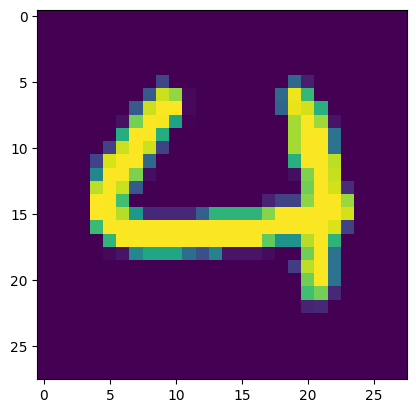

In [ ]:
plt.imshow(image_data[60])

In [ ]:
np.unique(labels, return_counts=True)

(array(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'], dtype=object),
 array([479, 563, 488, 493, 535, 434, 501, 550, 462, 495]))

In [ ]:
563/5000

0.1126

Majority Class Baseline: ~11%

In [ ]:
import seaborn as sns

In [ ]:
for_barplot = np.unique(labels, return_counts=True)

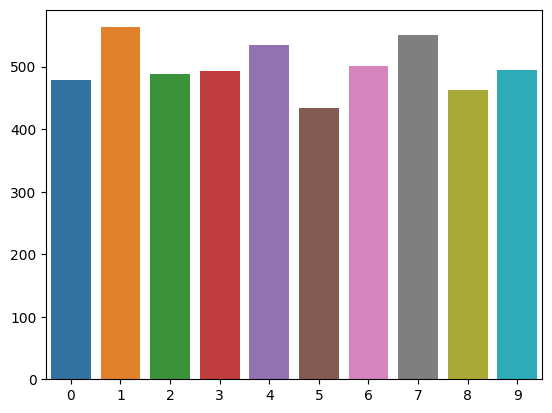

In [ ]:
sns.barplot(x = for_barplot[0], y = for_barplot[1]);

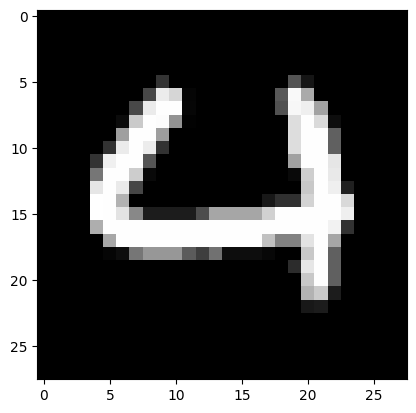

In [ ]:
test_image = image_data[60]
plt.imshow(test_image, cmap= "gray")

In [ ]:
test_image.shape

(28, 28)

In [ ]:
pd.DataFrame(test_image.reshape((28*28,1)))

,0
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0
...,...
779,0.0
780,0.0
781,0.0
782,0.0


In [ ]:
x = 0
while x < 5000:
  image = image_data[x]
  image = image.astype('float32')
  rgb_image = cv2.cvtColor(image,cv2.COLOR_GRAY2RGB)
  image_data[x] = rgb_image
  x+=1

ValueError: ignored

In [ ]:
X = image_data.reshape((5000,28,28,1))

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

In [ ]:
X_train.shape

(4000, 28, 28, 1)

In [ ]:
def plot_acc(history, ax = None, xlabel = 'Epoch #'):

    if hasattr(history, 'history_'):
      history = history.history_
    else:
      history = history.history
    history.update({'epoch':list(range(len(history['val_accuracy'])))})
    history = pd.DataFrame.from_dict(history)

    best_epoch = history.sort_values(by = 'val_accuracy', ascending = False).iloc[0]['epoch']

    if not ax:
      f, ax = plt.subplots(1,1)
    sns.lineplot(x = 'epoch', y = 'val_accuracy', data = history, label = 'Validation', ax = ax)
    sns.lineplot(x = 'epoch', y = 'accuracy', data = history, label = 'Training', ax = ax)
    ax.axhline(0.5, linestyle = '--',color='red', label = 'Chance')
    ax.axvline(x = best_epoch, linestyle = '--', color = 'green', label = 'Best Epoch')
    ax.legend(loc = 7)
    ax.set_ylim([0.4, 1])

    ax.set_xlabel(xlabel)
    ax.set_ylabel('Accuracy (Fraction)')

    plt.show()

In [ ]:
def train(model, x, y, x_val, y_val, lr, epochs):
  log_dir = "logs/" + model.name + "/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
  tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)
  print ("MODEL NAME:", model.name)
  optimizer = tf.optimizers.Adam(learning_rate=lr)
  model.compile(
      optimizer=optimizer,
      loss='sparse_categorical_crossentropy',
      metrics=["accuracy"],
  )
  return model.fit(
      x,
      y,
      epochs=epochs,
      validation_data=(x_val, y_val),
      callbacks=[tensorboard_callback],
      verbose=1,
  )


In [ ]:
conv_model = tf.keras.models.Sequential(
        [

            Conv2D(32, (4,4), activation="relu", input_shape=(28,28,1)),
            MaxPooling2D(),
            Conv2D(32, (4,4), activation="relu"),
            MaxPooling2D(),
            Conv2D(32, (4,4), activation="relu"),

            Flatten(),
            Dense(10, activation="softmax")

        ]
    )

In [ ]:
conv_model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_6 (Conv2D)           (None, 26, 26, 32)        320       
                                                                 
 max_pooling2d_4 (MaxPooling  (None, 13, 13, 32)       0         
 2D)                                                             
                                                                 
 conv2d_7 (Conv2D)           (None, 11, 11, 32)        9248      
                                                                 
 max_pooling2d_5 (MaxPooling  (None, 5, 5, 32)         0         
 2D)                                                             
                                                                 
 conv2d_8 (Conv2D)           (None, 3, 3, 32)          9248      
                                                                 
 flatten_2 (Flatten)         (None, 288)              

In [ ]:
conv_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
hist = conv_model.fit(X_train, y_train, epochs=30, validation_data=(X_test, y_test))

Epoch 1/30
125/125 [==============================] - 9s 71ms/step - loss: 1.3194e-04 - accuracy: 1.0000 - val_loss: 0.1713 - val_accuracy: 0.9680
Epoch 2/30
125/125 [==============================] - 8s 66ms/step - loss: 1.2276e-04 - accuracy: 1.0000 - val_loss: 0.1741 - val_accuracy: 0.9680
Epoch 3/30
125/125 [==============================] - 8s 62ms/step - loss: 1.1069e-04 - accuracy: 1.0000 - val_loss: 0.1766 - val_accuracy: 0.9660
Epoch 4/30
125/125 [==============================] - 9s 73ms/step - loss: 1.0519e-04 - accuracy: 1.0000 - val_loss: 0.1829 - val_accuracy: 0.9680
Epoch 5/30
125/125 [==============================] - 7s 59ms/step - loss: 9.5663e-05 - accuracy: 1.0000 - val_loss: 0.1818 - val_accuracy: 0.9660
Epoch 6/30
125/125 [==============================] - 7s 55ms/step - loss: 8.8846e-05 - accuracy: 1.0000 - val_loss: 0.1798 - val_accuracy: 0.9690
Epoch 7/30
125/125 [==============================] - 4s 30ms/step - loss: 8.1530e-05 - accuracy: 1.0000 - val_loss: 0

In [ ]:
np.average(hist.history['val_accuracy'])

0.9679999987284342

In [ ]:
# convert from integers to floats
train_norm = X_train.astype('float32')
test_norm = X_test.astype('float32')
# normalize to range 0-1
train_norm = train_norm / 255.0
test_norm = test_norm / 255.0

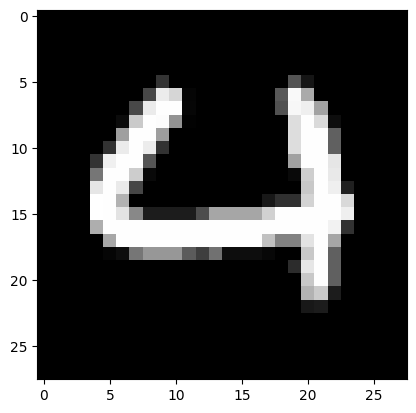

In [ ]:
plt.imshow(test_image, cmap= "gray")

In [ ]:
hist2 = conv_model.fit(X_train, y_train, epochs=30, validation_data=(X_test, y_test))

Epoch 1/30
125/125 [==============================] - 5s 40ms/step - loss: 1.3328e-05 - accuracy: 1.0000 - val_loss: 0.2033 - val_accuracy: 0.9670
Epoch 2/30
125/125 [==============================] - 4s 32ms/step - loss: 1.2325e-05 - accuracy: 1.0000 - val_loss: 0.1987 - val_accuracy: 0.9670
Epoch 3/30
125/125 [==============================] - 4s 28ms/step - loss: 1.1402e-05 - accuracy: 1.0000 - val_loss: 0.2072 - val_accuracy: 0.9660
Epoch 4/30
125/125 [==============================] - 4s 28ms/step - loss: 1.0650e-05 - accuracy: 1.0000 - val_loss: 0.2043 - val_accuracy: 0.9660
Epoch 5/30
125/125 [==============================] - 5s 43ms/step - loss: 9.8993e-06 - accuracy: 1.0000 - val_loss: 0.2068 - val_accuracy: 0.9650
Epoch 6/30
125/125 [==============================] - 4s 30ms/step - loss: 9.1038e-06 - accuracy: 1.0000 - val_loss: 0.2011 - val_accuracy: 0.9680
Epoch 7/30
125/125 [==============================] - 4s 30ms/step - loss: 8.5595e-06 - accuracy: 1.0000 - val_loss: 0

In [ ]:
np.average(hist2.history['val_accuracy'])

0.9659333388010661

In [ ]:
y_acc1 = y_true == y_pred1
y_acc2 = y_true == y_pred2

NameError: ignored

In [ ]:
hist.history

{'loss': [1.9570857286453247,
  0.6668272614479065,
  0.629497766494751,
  0.5913264751434326,
  0.5702105164527893,
  0.5307923555374146,
  0.5010530948638916,
  0.4653434157371521,
  0.43942365050315857,
  0.4109397232532501,
  0.3983791768550873,
  0.3838081657886505,
  0.3750668168067932,
  0.3714718818664551,
  0.35170072317123413,
  0.34099358320236206,
  0.337080717086792,
  0.33044856786727905,
  0.3285926878452301,
  0.3279199004173279,
  0.32748621702194214,
  0.31419098377227783,
  0.3247862160205841,
  0.2996465563774109,
  0.30887824296951294,
  0.3115572929382324,
  0.29809829592704773,
  0.3009239435195923,
  0.3113134503364563,
  0.29436346888542175],
 'accuracy': [0.6517500281333923,
  0.7894999980926514,
  0.7962499856948853,
  0.8054999709129333,
  0.8117499947547913,
  0.8267499804496765,
  0.8327500224113464,
  0.8522499799728394,
  0.8579999804496765,
  0.8705000281333923,
  0.8654999732971191,
  0.8802499771118164,
  0.8757500052452087,
  0.875,
  0.8837500214576

In [ ]:
hist2.history

{'loss': [0.2257521152496338,
  0.22446511685848236,
  0.22063015401363373,
  0.21969348192214966,
  0.22729915380477905,
  0.2153175175189972,
  0.21670547127723694,
  0.2120477706193924,
  0.22064466774463654,
  0.20892514288425446,
  0.20712052285671234,
  0.20661292970180511,
  0.20803235471248627,
  0.20407913625240326,
  0.19832023978233337,
  0.1995212286710739,
  0.2012205272912979,
  0.19431708753108978,
  0.20140668749809265,
  0.1992347538471222,
  0.1911950558423996,
  0.18889784812927246,
  0.19105841219425201,
  0.18847763538360596,
  0.18317943811416626,
  0.19271375238895416,
  0.18100020289421082,
  0.1958441287279129,
  0.18627303838729858,
  0.18197683990001678],
 'accuracy': [0.9237499833106995,
  0.9227499961853027,
  0.921999990940094,
  0.9300000071525574,
  0.9242500066757202,
  0.9297500252723694,
  0.9259999990463257,
  0.9269999861717224,
  0.9294999837875366,
  0.9290000200271606,
  0.9307500123977661,
  0.9317499995231628,
  0.9332500100135803,
  0.93150001

In [ ]:
data = [0],[0],[0],[0]
y_acc1 = int(hist.history['val_accuracy'][0])
y_acc2 = int(hist2.history['val_accuracy'][0])
np.unique((2 * y_acc1 + y_acc2),return_counts = True)


(array([0]), array([1]))

In [ ]:
data

(array([0]), array([1]))

In [ ]:
from scipy.stats import chisquare

In [ ]:
from statsmodels.stats.contingency_tables import mcnemar

In [ ]:
res = mcnemar(data, exact=False)

IndexError: ignored

In [ ]:
res.statistic

array([inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf,
       inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf,
       inf, inf])

In [ ]:
res.pvalue

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])